In [1]:
import pandas as pd
df=pd.read_csv('real_estate_preprocessed.csv')
df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,0.690424,5.0,4.0,7.600000,1.0,0.381197,0.700302,1.0,0.0,1.000000,1.327625
1,100002,0.101317,3.0,3.0,6.300000,1.0,0.526719,0.268813,1.0,0.0,0.071429,0.566003
2,100003,0.810017,4.0,3.0,5.800000,1.0,0.698079,0.060065,0.0,0.0,0.100000,0.734562
3,100004,1.357822,5.0,3.0,5.610638,1.0,0.204188,0.060065,1.0,1.0,0.200000,1.453055
4,100005,-0.002070,3.0,3.0,3.800000,1.0,0.782714,-0.300670,0.0,0.0,0.062500,-0.226520


* Implement Polynomial Regression (degree 2 or 3).

In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X = df.drop(['house_price_inr', 'house_id'], axis=1)
y = df['house_price_inr']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

poly2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

model_poly2 = LinearRegression()
model_poly2.fit(X_train_poly2, y_train)

y_pred_poly2 = model_poly2.predict(X_test_poly2)

In [4]:
print('coefficient:',model_poly2.coef_)
print()
print('intercept:',model_poly2.intercept_)

coefficient: [-4.00339253e-16  1.55062909e-01  9.24386845e-02  1.50084916e-02
  2.35615572e-01  1.49186219e-16 -1.54575113e-01  1.46066536e-01
  6.02996854e-02  1.82699468e-02  1.29373083e-01 -4.49312164e-02
  6.02542619e-02 -7.29881119e-03  2.16007921e-02  1.55062909e-01
 -6.56243894e-02  6.14450340e-02  6.03048835e-02 -5.87846207e-02
  1.00575275e-03 -1.84366993e-02  7.31984888e-03 -1.31788262e-02
  9.24386845e-02  5.95990777e-02 -5.09245731e-02 -2.46445010e-03
  4.30489459e-02  1.73480305e-02 -2.63330838e-03  3.86294013e-03
  1.50084916e-02  6.05393872e-03 -1.80560805e-02 -3.25920835e-02
 -1.60704093e-02 -4.92391623e-02 -1.69955407e-02  2.35615572e-01
 -7.65027886e-04  7.39751624e-03 -8.20232265e-03  1.69899550e-03
 -1.69988859e-02 -2.77555756e-17 -1.54575113e-01  1.46066536e-01
  6.02996854e-02  1.82699468e-02  1.29373083e-01 -2.27105727e-01
 -1.47266312e-02  1.38884705e-02 -1.53867277e-01  4.24979034e-02
 -7.59148698e-03  1.44250147e-03 -2.21225884e-02 -7.44759823e-02
  6.02996854

* Model evaluation

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_error
import numpy as np

print('mae:', mean_absolute_error(y_test, y_pred_poly2))
print('rmse:', np.sqrt(mean_squared_error(y_test, y_pred_poly2)))
print('r2:', r2_score(y_test, y_pred_poly2))
print('mse:', mean_squared_error(y_test, y_pred_poly2))

mae: 0.2727429024632312
rmse: 0.41710365519513654
r2: 0.837726104666989
mse: 0.17397545917714335


* Polynomial curve

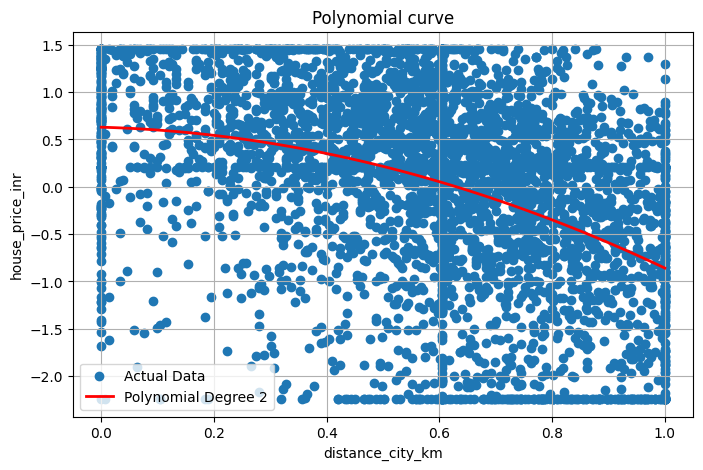

In [6]:
import matplotlib.pyplot as plt

X_vis = df[['distance_city_km']].values
y_vis = df['house_price_inr'].values

poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X_vis)

model_poly2 = LinearRegression()
model_poly2.fit(X_poly2, y_vis)

X_range = np.linspace(X_vis.min(), X_vis.max(), 100).reshape(-1,1)
plt.figure(figsize=(8,5))
plt.scatter(X_vis, y_vis, label="Actual Data")
plt.plot(X_range, model_poly2.predict(poly2.transform(X_range)), color='red', label="Polynomial Degree 2", linewidth=2)

plt.xlabel("distance_city_km")
plt.ylabel("house_price_inr")
plt.title("Polynomial curve")

plt.legend()
plt.grid()
plt.show()

* Residual and homoscadasticity

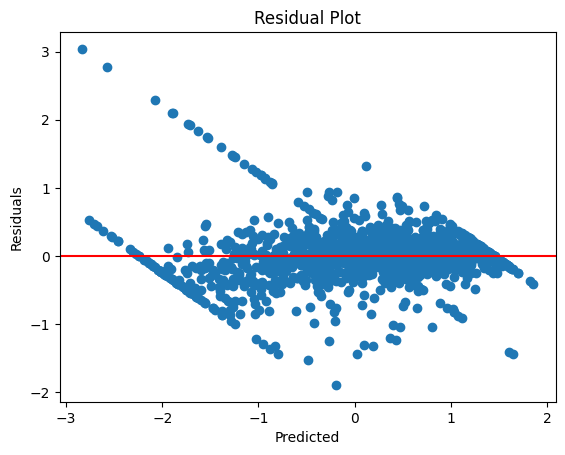

In [7]:
residuals = y_test - y_pred_poly2

plt.scatter(y_pred_poly2, residuals)
plt.axhline(y=0, color='red')
plt.title('Residual Plot')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.show()

* Identify Overfit or underfit

In [8]:
print("Train Score:", model_poly2.score(X_train_poly2[:,1:4], y_train))
print("Test Score:", model_poly2.score(X_test_poly2[:,1:4], y_test))

Train Score: -18.42313335269012
Test Score: -15.974070850145598


It is underfit because both training and testing has very low score.  
Model is simple and linear and datset is very large and complex.